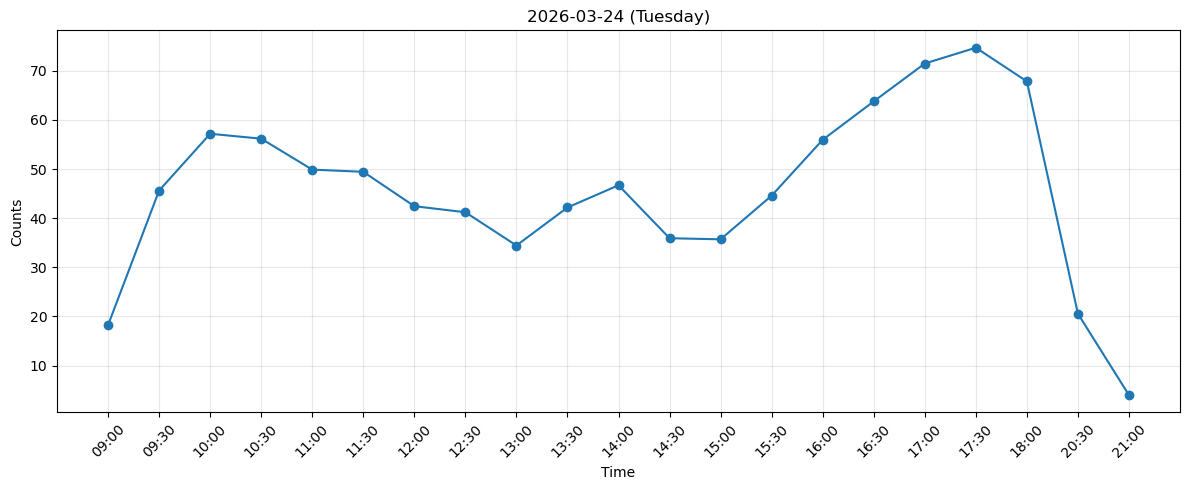

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

CSV_NAME = "gym_count_2026-03-24.csv"

DATA_DIR = "./gym_count"
FILE_PATH = os.path.join(DATA_DIR, CSV_NAME)

df = pd.read_csv(FILE_PATH)

# 轉時間格式
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

# 只保留 09:00 ~ 21:00
df = df[
    (df["timestamp"].dt.hour >= 9) &
    (
        (df["timestamp"].dt.hour < 21) |
        ((df["timestamp"].dt.hour == 21) & (df["timestamp"].dt.minute == 0))
    )
].copy()

if df.empty:
    raise ValueError("這一天 09:00~21:00 沒有資料")

# 建立半小時區間
df["time_bin"] = df["timestamp"].dt.floor("30min")

# 每半小時平均
avg_df = df.groupby("time_bin", as_index=False)["count"].mean()

# x 軸只顯示左邊界
avg_df["time_label"] = avg_df["time_bin"].dt.strftime("%H:%M")

# 抓日期 
plot_date = CSV_NAME.replace("gym_count_", "").replace(".csv", "")
plot_datetime = pd.to_datetime(plot_date)
weekday_str = plot_datetime.strftime("%A")
title_str = f"{plot_date} ({weekday_str})"

# plt
plt.figure(figsize=(12, 5))
plt.plot(avg_df["time_label"], avg_df["count"], marker="o")

plt.title(title_str)
plt.xlabel("Time")
plt.ylabel("Counts")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()


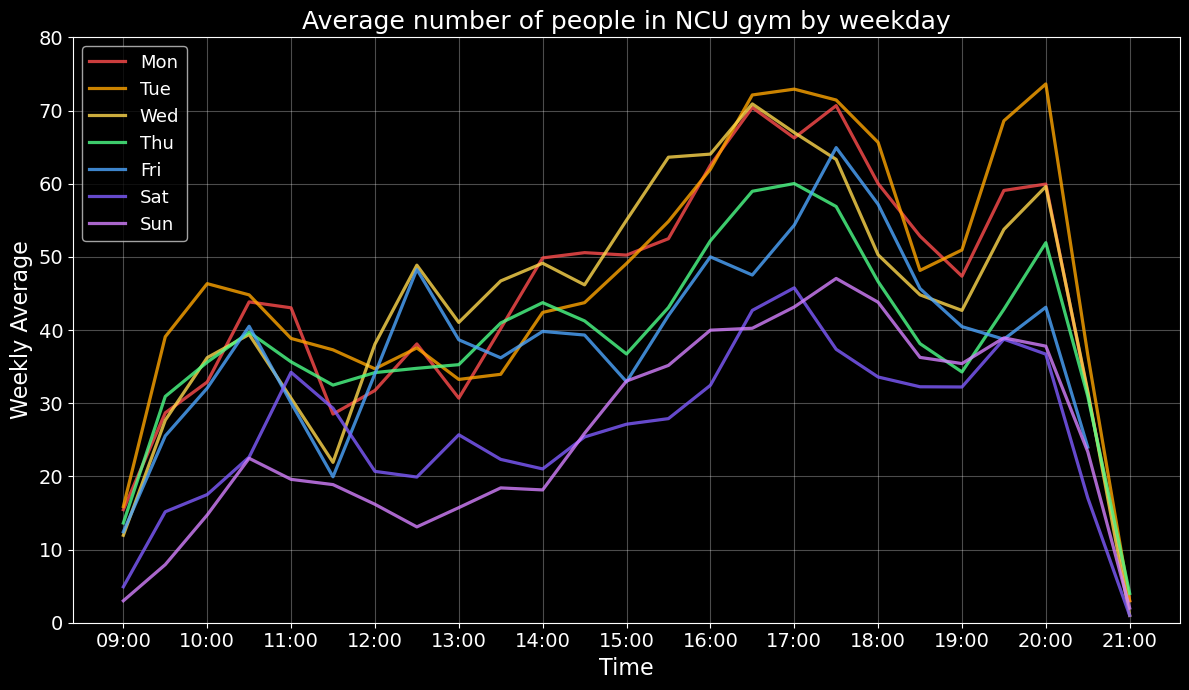

In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "./gym_count"

weekday_colors = {
    0: "#ff4d4d",  # Monday - bright red
    1: "#ffa500",  # Tuesday - orange
    2: "#ffd84d",  # Wednesday - bright yellow
    3: "#4dff88",  # Thursday - green
    4: "#4da6ff",  # Friday - blue
    5: "#7f5cff",  # Saturday - indigo
    6: "#d580ff"   # Sunday - violet
}

weekday_labels = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "gym_count_*.csv")))

if not csv_files:
    raise FileNotFoundError("在 ./gym_count 找不到 gym_count_*.csv")

# 收集所有日期整理後的半小時平均資料
all_avg_list = []

for file_path in csv_files:
    file_name = os.path.basename(file_path)
    plot_date = file_name.replace("gym_count_", "").replace(".csv", "")

    try:
        plot_datetime = pd.to_datetime(plot_date)
    except Exception:
        print(f"跳過檔名格式不符的檔案: {file_name}")
        continue

    weekday = plot_datetime.weekday()

    df = pd.read_csv(file_path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    # 只保留 09:00 ~ 21:00
    df = df[
        (df["timestamp"].dt.hour >= 9) &
        (
            (df["timestamp"].dt.hour < 21) |
            ((df["timestamp"].dt.hour == 21) & (df["timestamp"].dt.minute == 0))
        )
    ].copy()

    if df.empty:
        print(f"{file_name} 在 09:00~21:00 沒有資料，跳過")
        continue

    # 半小時平均
    df["time_bin"] = df["timestamp"].dt.floor("30min")
    avg_df = df.groupby("time_bin", as_index=False)["count"].mean()

    # 只保留時間字串，讓不同日期的同一時段可以對齊
    avg_df["time_label"] = avg_df["time_bin"].dt.strftime("%H:%M")
    avg_df["weekday"] = weekday

    all_avg_list.append(avg_df[["weekday", "time_label", "count"]])

if not all_avg_list:
    raise ValueError("所有檔案都沒有可用資料")

# 合併所有天的半小時平均資料
all_avg_df = pd.concat(all_avg_list, ignore_index=True)

# 再把同 weekday、同 time_label 的資料平均 => 最終每個 weekday 只剩一條線
weekly_pattern_df = (
    all_avg_df
    .groupby(["weekday", "time_label"], as_index=False)["count"]
    .mean()
)

# 建立排序用時間
weekly_pattern_df["time_sort"] = pd.to_datetime(
    weekly_pattern_df["time_label"], format="%H:%M"
)

# X 軸只顯示整點
hour_labels = [f"{h:02d}:00" for h in range(9, 22)]

# 畫圖
plt.style.use("dark_background")
plt.figure(figsize=(12, 7))

for weekday in range(7):
    day_df = weekly_pattern_df[weekly_pattern_df["weekday"] == weekday].copy()

    if day_df.empty:
        continue

    day_df = day_df.sort_values("time_sort")

    plt.plot(
        day_df["time_label"],
        day_df["count"],
        marker="none",
        markersize=4, 
        linewidth=2.3,
        color=weekday_colors[weekday],
        alpha=0.8,
        label=weekday_labels[weekday]
    )
plt.title("Average number of people in NCU gym by weekday", fontsize=18)
plt.ylim(0, 80)
plt.xlabel("Time", fontsize=16)
plt.ylabel("Weekly Average", fontsize=16)
plt.grid(True, alpha=0.3)

plt.xticks(hour_labels, rotation=0, fontsize=14)
plt.yticks(fontsize=14)

plt.legend(loc="upper left", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
#just for test003